## Basic example

This illustratres use of postprocessing functions to transform downloaded forecast data and observed data into structure enabling simultaneous analyses 

In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
#import datetime
#import os,sys,glob
#import xesmf as xe
#import warnings
#warnings.filterwarnings("ignore", category=RuntimeWarning)
#import pooch
from acacia_s2s_toolkit.postprocess import postprocess_forecast, get_example_data, load_raw_data

In [2]:
# let's see what the preprocess function does
print(postprocess_forecast.__doc__)


End-to-end postprocessing pipeline for forecast, hindcast, and observations.

This function performs all postprocessing steps required to prepare
forecast, hindcast, and observational datasets for verification or
downstream analysis. The workflow includes:

1. Reading forecast, hindcast, and observation NetCDF files.
2. Converting accumulated variables to daily totals (when required).
3. Spatial grid alignment between model data and observations.
4. Temporal alignment of observations with hindcast structure.
5. Reshaping datasets into a lead-time oriented format.
6. Temporal aggregation over user-defined windows (e.g. 5-day, 7-day).

The output datasets share a consistent structure that allows direct
comparison between hindcasts, forecasts, and observations.

Parameters
----------
nominal_date : str or datetime-like
    Nominal initialization date of the forecast. Used to identify
    the forecast and hindcast files and to align hindcasts with the
    forecast cycle.

download_dir : s

## Getting some example data to work with

In [3]:
#this is the data directory - you can change it as it suits you
data_dir="./data"

# this will load example data used in this notebook
# data are available at https://web.csag.uct.ac.za:~wolski/acacia/toolkit/
# comment this line if you want to work with your own data - 
# you will then have to define a file with observational data, and have 
# forecast and hindcast data for given initialization date downloaded to
# the data_dir

get_example_data(data_dir)

file already exists locally ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_hc.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_fc.nc
file already exists locally ./data/madagascar.geojson


True

## Defining parameters for postprocessing

In [4]:
# defining what you want to process - i.e. forecast date, domain and observed dataset

# nominal forecast date is defined here. 
# This notebook uses example data for this date only
# example data are downloaded by a function get_example_data() called above

nominal_date="2026-03-01"
#target domain
target_domain="madagascar"
#forecast variable
fcst_var="tp"
#foreast model
fcst_model="ECMWF"

#this is file with observational data. It is gridded and covers the period of Jan 1981-March 2026
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"

#we have to provide the name of the variable stored in the obs_file
obs_var="PRCPTOT"

# this is a file with vector data showing the boundaries of the domain - will be used in plotting only
domain_shape_file=f"{data_dir}/madagascar.geojson"

# data will be aggregated into blocks of this size - "5D" is a Pandas expression of temporal base and stands for 5 days
# if you want differently sized blocks - just change it into, say "7D"
agg_window="5D"

#and this defines how data will be aggreagated over the block - in this case it will be a sum of daily values
agg_method="sum"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the spatial overlap between obs and forecast grids of less than fractional 
# threshold
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}

## Running the postprocessing function

In [5]:

# calling the preprocessing function
# the function returns three objects: transformed hindcast data, transformed hindcast data and transformed observations
# we use _lt suffix here, which stands for lead time - as the transformation gives a lead time-oriented structure of the data. 
# the details of this structure will be exlained below.
hindcast_lt,forecast_lt,obs_lt=postprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    grid_alignment_kwargs=grid_alignment_kwargs,
    time_alignment_kwargs=time_alignment_kwargs,
    verbose=True
)

logging is True
logging is on
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT

==================== START: read_netcdf ====================

reading tp from ./data/tp_ECMWF_20260301_madagascar_fc.nc
success
looking for tp
found
Harmonizing coordinates...
Renaming coordinates: {'latitude': 'lat', 'longitude': 'lon', 'time': 'time'}
check if data are daily...
daily with data time range: 2026-03-02T00:00:00.000000000 to 2026-03-28T00:00:00.000000000
all done



==================== START: read_netcdf ====================

reading tp from ./data/tp_ECMWF_20260301_madagascar_hc.nc
success
looking for tp
found
Harmonizing coordinates...
Renaming coordinates: {'latitude': 'lat', 'longitude': 'lon', 'time': 'time'}
check if data are daily...
daily with data time range: 2006-03-02T00:00:00.000000000 to 2025-03-28T00:00:00.

## Structure of transformed data

In [8]:
# to illustrate difference between the raw data and the transformed data, let's load the raw data first
# the postprocessing package offers a function for this:

hindcast_raw,forecast_raw,obs_raw=load_raw_data(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    obs_file=obs_file,
    obs_var=obs_var,
    verbose=False
)

logging is False
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT


In [10]:
#Now we can compare the raw and transformed datasets:
print("hindcast:")
print("raw hindcast", hindcast_raw.dims, hindcast_raw.shape)
print("processed hindcast", hindcast_lt.dims, hindcast_lt.shape)

print("\nforecast:")
print("raw forecast", forecast_raw.dims, forecast_raw.shape)
print("processed forecast", forecast_lt.dims, forecast_lt.shape)

print("\nobservations:")
print("raw observations", obs_raw.dims, obs_raw.shape)
print("processed observations", obs_lt.dims, obs_lt.shape)

hindcast:
raw hindcast ('time', 'member', 'lat', 'lon') (540, 11, 10, 6)
processed hindcast ('init_date', 'member', 'lead_time', 'lat', 'lon') (20, 11, 5, 10, 6)

forecast:
raw forecast ('time', 'member', 'lat', 'lon') (27, 101, 10, 6)
processed forecast ('init_date', 'member', 'lead_time', 'lat', 'lon') (1, 101, 5, 10, 6)

observations:
raw observations ('time', 'lat', 'lon') (16467, 58, 36)
processed observations ('init_date', 'lead_time', 'lat', 'lon') (20, 5, 10, 6)


What the postprocessing function does is the following for hindcast and forecast data 
- it disaggregates the time dimension, which in raw data pools hindcasts (and separately forecasts) across the downloaded initiatlization times into two dimensions - initialization time (init_date) and lead time (lead_time).
- the size of init_date corresponds to the number of years in hindcast and forecast. Obviously - it is 1 for forecast.
- Note that in case you downloaded forecast or hindcasts with a number of rf_enslags or fc_enslags, the disaggregation into init_date is performed "by hindcast of forecast year", i.e. all data initialized within a particular year will be pooled together under one init_date.
- the size of lead_time dimension corresponds to the number of temporal "blocks" fitting into the time series of the forecast data. With forecast run with lead time up to XX days, and the size of postprocessing "block" set to 5D - we get 5 lead time blocks
- data for each lead_time will be aggregated over its corresponding time base (so over day 1 to 5 for lead_time of 1, day 6 to 10 for lead_time of 2 etc.)
  
For observations:
- the postprocessing function reorganizes the data into the same init_date and lead_time "blocks" as are derived for the hindcast. Obviously, observations are not available for the forecast period, so there is no observed data matching the forecast.

Additionally, depending on the user-defined argument - direction - which is either "fine_to_coarse" or "coarse_to_fine", the postprocessing function aligns the spatial grids of observations and forecast. 
In the above example, the argument was "fine_to_coarse", which resulted in observations data grid (fine) to be resampled to the forecast data grid (coarse). This is illustrated in figures below.

## Aligning forecast and observed spatial grids

logging is False
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT
here
postprocessing done


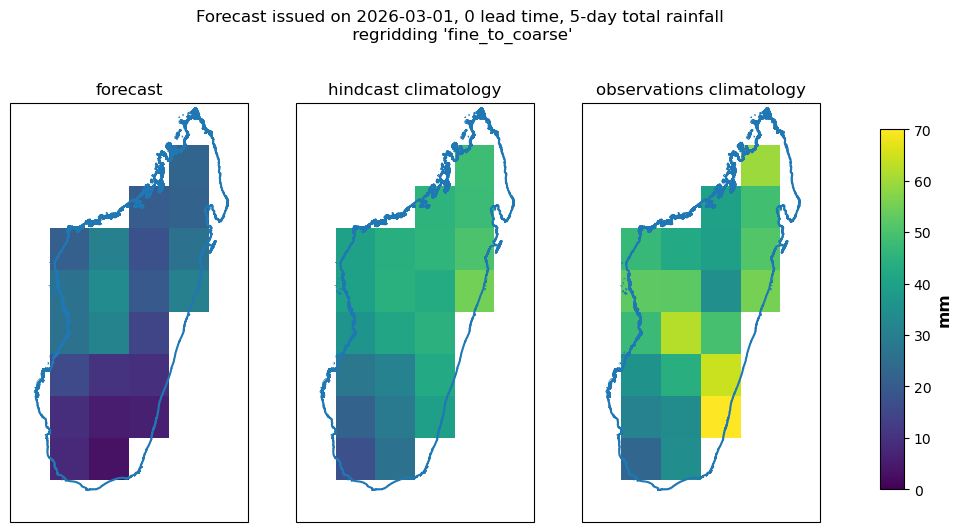

In [42]:
#To illustrate how the spatial grids are aligned let's plot data 

#first for the "fine_to_coarse"
# we will reprocess the data to make sure we are doing things right

#setting direction argument to "fine_to_coarse"
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

#reprocessing data
hindcast_lt,forecast_lt,obs_lt=postprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    grid_alignment_kwargs=grid_alignment_kwargs,
    time_alignment_kwargs=time_alignment_kwargs,
    verbose=False
)

#selecting a lead time for plotting
lead_time=0

# selecting data for this lead time
fcst=forecast_lt.sel(lead_time=lead_time)

#for obs and hindcast we get climatology for the given lead_time
obs=obs_lt.sel(lead_time=lead_time).mean("init_date")
hcst=hindcast_lt.sel(lead_time=lead_time).mean("init_date")


#let's plot ensemble median
fcst=fcst.mean("member")
hcst=hcst.mean("member")
#obviously - observations are not an ensemble, so no need to do anything


#plotting figure
fig=plt.figure(figsize=(12,6))

#plotting forecast map
pl=fig.add_subplot(1,3,1, projection=ccrs.PlateCarree())
im=fcst.plot(add_colorbar=False, vmin=0, vmax=70)
pl.set_title("forecast")

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

#plotting hindcast map
pl=fig.add_subplot(1,3,2, projection=ccrs.PlateCarree())
im=hcst.plot(add_colorbar=False, vmin=0, vmax=70)
pl.set_title("hindcast climatology")

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

# plotting observed data
pl=fig.add_subplot(1,3,3, projection=ccrs.PlateCarree())
im=obs.plot(add_colorbar=False, vmin=0, vmax=70)
pl.set_title("observations climatology")

#adding colorbar
ax=fig.add_axes([0.85,0.2,0.02,0.6])
cbar = plt.colorbar(im, cax=ax)
cbar.set_label('mm', size=12, weight='bold')
#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall\n regridding 'fine_to_coarse'".format(nominal_date, lead_time, agg_window[:-1]), y=1)
plt.subplots_adjust(right=0.8)
plt.show()

logging is False
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT
here
postprocessing done


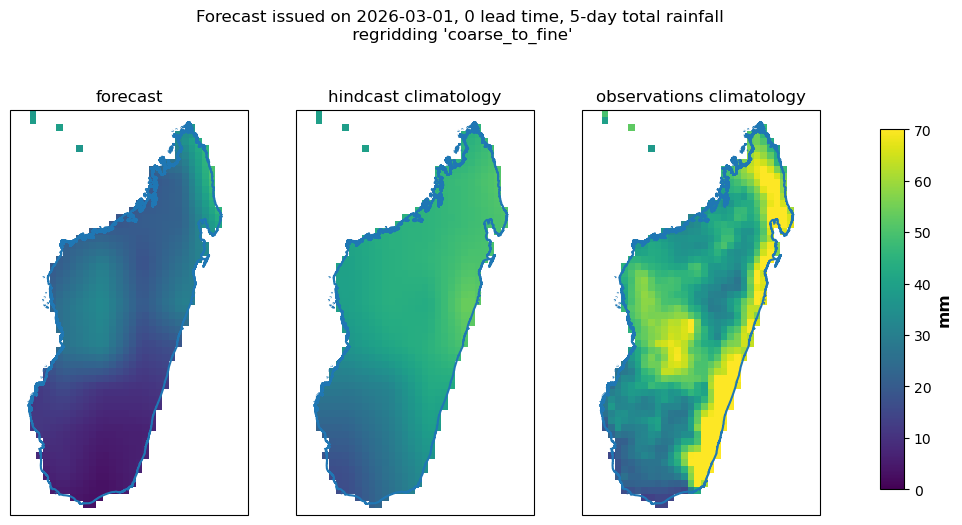

In [44]:
#Let's repeat this with "coarse_to_fine" 

# we will reprocess the data to make sure we are doing things right

#setting direction argument to "coarse_to_fine"
grid_alignment_kwargs=dict(
    direction="coarse_to_fine",
    method="bilinear",
    raise_if_missing=True,
    threshold=0.9
)

#reprocessing data
hindcast_lt,forecast_lt,obs_lt=postprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    grid_alignment_kwargs=grid_alignment_kwargs,
    time_alignment_kwargs=time_alignment_kwargs,
    verbose=False
)

#selecting a lead time for plotting
lead_time=0

# selecting data for this lead time
fcst=forecast_lt.sel(lead_time=lead_time)

#for obs and hindcast we get climatology for the given lead_time
obs=obs_lt.sel(lead_time=lead_time).mean("init_date")
hcst=hindcast_lt.sel(lead_time=lead_time).mean("init_date")


#let's plot ensemble median
fcst=fcst.mean("member")
hcst=hcst.mean("member")
#obviously - observations are not an ensemble, so no need to do anything


#plotting figure
fig=plt.figure(figsize=(12,6))

#plotting forecast map
pl=fig.add_subplot(1,3,1, projection=ccrs.PlateCarree())
im=fcst.plot(add_colorbar=False, vmin=0, vmax=70)
pl.set_title("forecast")

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

#plotting hindcast map
pl=fig.add_subplot(1,3,2, projection=ccrs.PlateCarree())
im=hcst.plot(add_colorbar=False, vmin=0, vmax=70)
pl.set_title("hindcast climatology")

#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

# plotting observed data
pl=fig.add_subplot(1,3,3, projection=ccrs.PlateCarree())
im=obs.plot(add_colorbar=False, vmin=0, vmax=70)
pl.set_title("observations climatology")

#adding colorbar
ax=fig.add_axes([0.85,0.2,0.02,0.6])
cbar = plt.colorbar(im, cax=ax)
cbar.set_label('mm', size=12, weight='bold')
#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)
plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall\n regridding 'coarse_to_fine'".format(nominal_date, lead_time, agg_window[:-1]), y=1)
plt.subplots_adjust(right=0.8)
plt.show()